## 一元线性回归

In [53]:
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

In [54]:
import warnings
warnings.filterwarnings("ignore")

In [55]:
housing = fetch_california_housing()  # 加载加州房价数据集

In [56]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [57]:
X = housing.data[:, 0].reshape(-1, 1)  # 选择MedInc作为唯一特征,并且将一维数据转换为二维特征矩阵

In [58]:
y = housing.target  # 房价中位数作为目标值

In [59]:
X = X[y < 5]  # 删除目标值大于等于 5 的样本，减少房价上限截断对回归模型的影响
y = y[y < 5]  # 使用相同条件过滤目标值，保证 X 和 y 的样本一一对应

In [60]:
print(X.shape)
print(y.shape)
print(housing.feature_names)

(19648, 1)
(19648,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


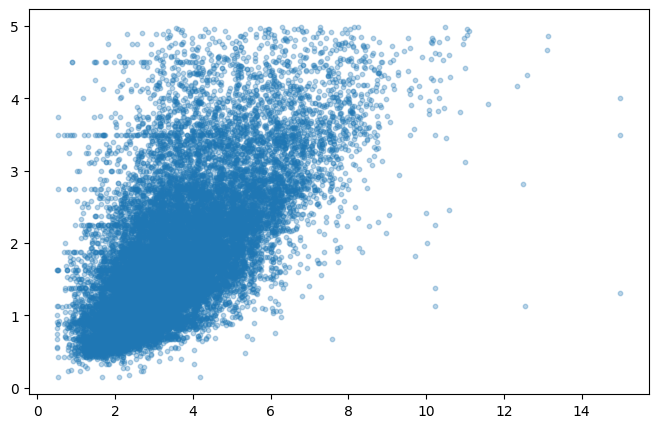

In [61]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.3, s=10)
plt.show()

## 划分数据集

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=233, shuffle=True)

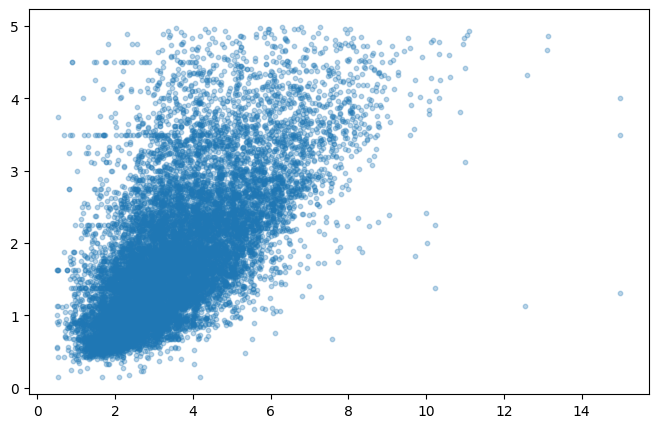

In [64]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.3, s=10)
plt.show()

## 一元线性回归公式实现

In [65]:
def fit(X, y):
    x = np.asarray(X).ravel()    # 将输入数据转换为一维 NumPy 数组，避免广播问题
    y = np.asarray(y).ravel()
    a_up = np.sum((x - np.mean(x)) * (y - np.mean(y)))  # 计算斜率公式的分子
    a_bottom = np.sum((x - np.mean(x)) ** 2)  # 计算斜率公式的分母
    a = a_up / a_bottom  # 计算回归直线的斜率
    b = np.mean(y) - a * np.mean(x)  # 计算回归直线的截距
    return a, b

In [66]:
a, b = fit(X_train, y_train)  # 使用训练集计算回归直线的斜率 a 和截距 b
a, b

(np.float64(0.39956389723725183), np.float64(0.4517688379191074))

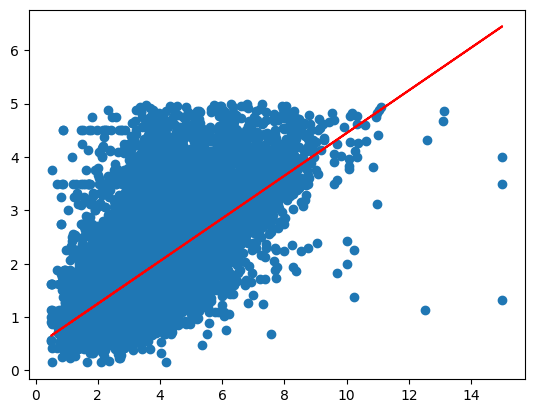

In [67]:
plt.scatter(X_train, y_train)
plt.plot(X_train, a * X_train + b, c="r")
plt.show()

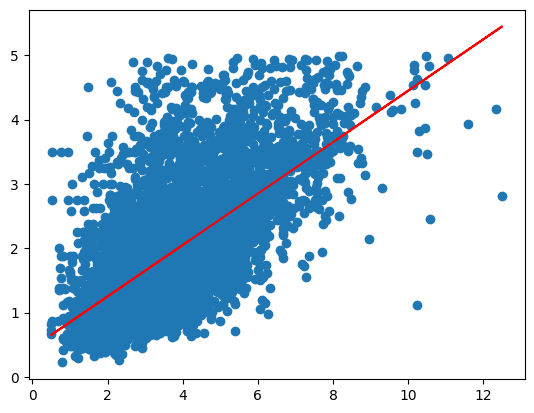

In [68]:
plt.scatter(X_test, y_test)
plt.plot(X_test, a * X_test + b, c="r")
plt.show()

## sklearn实现一元线性回归

In [69]:
from sklearn.linear_model import LinearRegression  # 导入线性回归模型

In [70]:
lin_reg = LinearRegression()  # 创建线性回归模型

In [71]:
lin_reg.fit(X_train.reshape(-1, 1), y_train);  # 使用训练集训练模型，reshape(-1, 1) 将特征转换为二维特征矩阵

In [72]:
y_predict = lin_reg.predict(X_test.reshape(-1, 1))  # 使用测试集进行预测

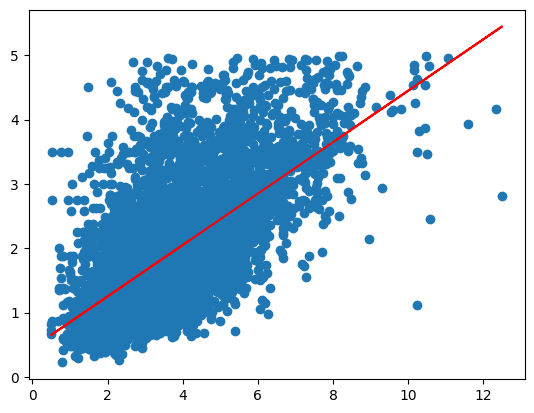

In [73]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_predict, c="r")
plt.show()

## 多元线性回归

In [74]:
X = housing.data
y = housing.target

In [75]:
X = X[y < 5]  # 删除目标值大于等于 5 的样本，减少房价上限截断对回归模型的影响
y = y[y < 5]  # 使用相同条件过滤目标值，保证 X 和 y 的样本一一对应

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=233, shuffle=True)

In [77]:
lin_reg.fit(X_train, y_train);

In [78]:
lin_reg.score(X_test, y_test)

0.5660501312759854